In [9]:
# Nombre de clusters optimisé trouvé par Optuna
n_clusters = study.best_params["n_components"]
print(f"Nombre optimal de clusters : {n_clusters}")

Nombre optimal de clusters : 8


[I 2026-05-03 14:35:26,671] A new study created in memory with name: no-name-fda23f3a-b9d0-459c-a880-ea949ca538d7
[I 2026-05-03 14:35:27,138] Trial 0 finished with value: 0.07485735658887915 and parameters: {'n_components': 5, 'covariance_type': 'diag', 'init_params': 'kmeans', 'max_iter': 167}. Best is trial 0 with value: 0.07485735658887915.
[I 2026-05-03 14:35:27,317] Trial 1 finished with value: 0.007122928743493537 and parameters: {'n_components': 8, 'covariance_type': 'spherical', 'init_params': 'random', 'max_iter': 284}. Best is trial 0 with value: 0.07485735658887915.
[I 2026-05-03 14:35:27,638] Trial 2 finished with value: 0.08740144631710528 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'init_params': 'kmeans', 'max_iter': 114}. Best is trial 2 with value: 0.08740144631710528.
[I 2026-05-03 14:35:27,851] Trial 3 finished with value: 0.039719633308303984 and parameters: {'n_components': 3, 'covariance_type': 'diag', 'init_params': 'random', 'max_iter': 2

[I 2026-05-03 14:35:42,146] Trial 33 finished with value: 0.08740144631710528 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'init_params': 'kmeans', 'max_iter': 131}. Best is trial 10 with value: 0.08938559605205194.
[I 2026-05-03 14:35:42,400] Trial 34 finished with value: 0.007122928743493537 and parameters: {'n_components': 8, 'covariance_type': 'spherical', 'init_params': 'random', 'max_iter': 277}. Best is trial 10 with value: 0.08938559605205194.
[I 2026-05-03 14:35:42,809] Trial 35 finished with value: 0.08740144631710528 and parameters: {'n_components': 7, 'covariance_type': 'spherical', 'init_params': 'kmeans', 'max_iter': 402}. Best is trial 10 with value: 0.08938559605205194.
[I 2026-05-03 14:35:43,262] Trial 36 finished with value: 0.08938559605205194 and parameters: {'n_components': 8, 'covariance_type': 'spherical', 'init_params': 'kmeans', 'max_iter': 308}. Best is trial 10 with value: 0.08938559605205194.
[I 2026-05-03 14:35:43,511] Trial 37 finish

Meilleurs paramètres GMM :
{'n_components': 8, 'covariance_type': 'spherical', 'init_params': 'kmeans', 'max_iter': 100}
Profil des clusters : Moyennes et Écarts-types
        Reading_Comprehension_Score           Listening_Accuracy            \
                               mean       std               mean       std   
Cluster                                                                      
0                         -0.120761  0.982278           0.630612  0.787957   
1                          0.604599  0.839838           0.381763  0.913983   
2                         -0.579648  0.819420           0.901132  0.621146   
3                         -0.738947  0.724051          -0.400413  0.836551   
4                          0.464965  0.837315          -0.949772  0.584768   
5                         -0.724590  0.674949          -0.359957  0.870733   
6                          0.171903  0.938631           0.032910  0.945495   
7                          0.795560  0.679431       

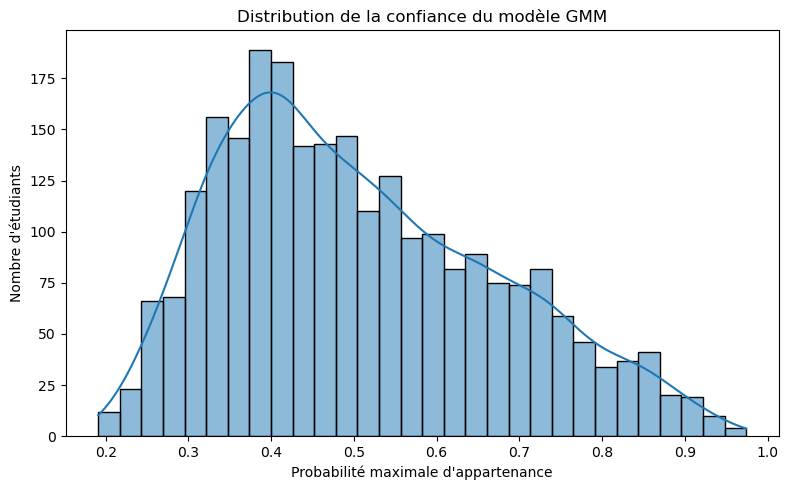

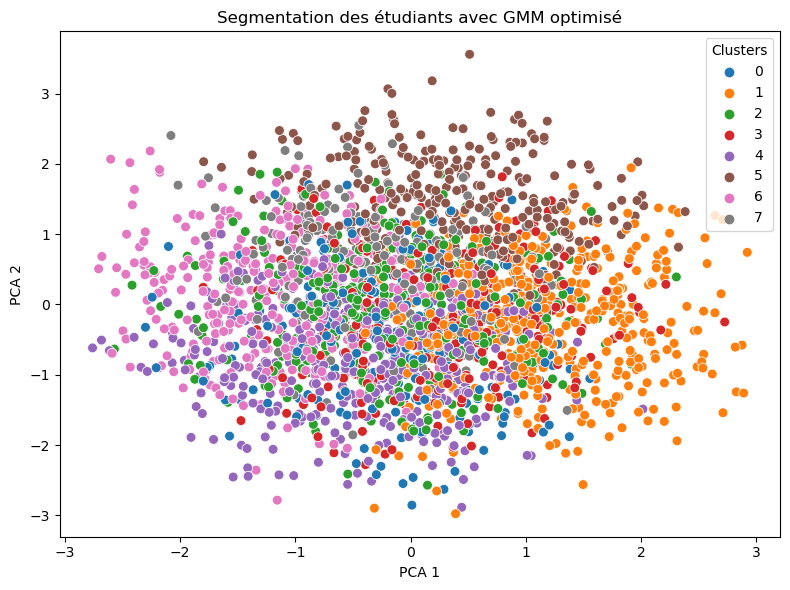

Silhouette Score : 0.08938559605205194
Davies-Bouldin Score : 2.0236542570670126
Calinski-Harabasz Score : 169.5808409448865
AIC : 56817.9572145715
BIC : 57278.056849429144


In [7]:
# Installer les bibliothèques nécessaires si ce n'est pas déjà fait
# !pip install optuna matplotlib seaborn scikit-learn pandas numpy

import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Charger le dataset (à remplacer par ton dataset)
df = pd.read_csv("Adaptive_English_Learning_Dataset (1).csv")  # Remplace par ton fichier

# Liste des features à utiliser
features = [
    "Reading_Comprehension_Score",
    "Listening_Accuracy",
    "Writing_Score",
    "Speaking_Score",
    "Engagement_Level",
    "Confidence_Rating",
    "Task_Difficulty",
    "Reward_Signal"
]

# Sélectionner les données d'entrée
X = df[features]

# Normalisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fonction objective pour l'optimisation de GMM avec Optuna
def objective_gmm(trial):
    n_components = trial.suggest_int("n_components", 2, 8)  # Nombre de clusters
    covariance_type = trial.suggest_categorical("covariance_type", ["full", "tied", "diag", "spherical"])
    init_params = trial.suggest_categorical("init_params", ["kmeans", "random"])  # Méthode d'initialisation
    max_iter = trial.suggest_int("max_iter", 100, 500)  # Nombre d’itérations maximales

    # Créer et entraîner le modèle GMM
    model = GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        init_params=init_params,
        max_iter=max_iter,
        random_state=42
    )
    labels = model.fit_predict(X_scaled)

    # Calculer le Silhouette Score pour évaluer la séparation des clusters
    if len(np.unique(labels)) < 2:  # Si tous les points sont dans un seul cluster
        return -1
    score = silhouette_score(X_scaled, labels)
    return score

# Optimisation avec Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective_gmm, n_trials=50)

# Afficher les meilleurs paramètres trouvés par Optuna
print("Meilleurs paramètres GMM :")
print(study.best_params)

# Entraîner le modèle avec les meilleurs paramètres trouvés par Optuna
best_gmm = GaussianMixture(
    n_components=study.best_params["n_components"],
    covariance_type=study.best_params["covariance_type"],
    init_params=study.best_params["init_params"],
    max_iter=study.best_params["max_iter"],
    random_state=42
)

# Entraîner le meilleur modèle
best_labels = best_gmm.fit_predict(X_scaled)

# Profiling des clusters : calcul des moyennes et écarts-types pour chaque cluster
df_clustered = pd.DataFrame(X_scaled, columns=features)
df_clustered["Cluster"] = best_labels  # Ajouter les labels des clusters à la dataframe
cluster_profiles = df_clustered.groupby("Cluster").agg(['mean', 'std'])

# Afficher les moyennes et écarts-types pour chaque cluster
print("Profil des clusters : Moyennes et Écarts-types")
print(cluster_profiles)

# Analyser les probabilités d'appartenance des étudiants à chaque cluster
proba = best_gmm.predict_proba(X_scaled)

# Créer un DataFrame avec les probabilités et les clusters
df_proba = pd.DataFrame(proba)
df_proba["Cluster"] = best_labels
df_proba["Max_Probability"] = proba.max(axis=1)

# Afficher les probabilités maximales d'appartenance
print("Probabilité maximale d'appartenance de chaque étudiant:")
print(df_proba.head())

# Visualiser la distribution des probabilités d'appartenance
plt.figure(figsize=(8, 5))
sns.histplot(df_proba["Max_Probability"], bins=30, kde=True)
plt.title("Distribution de la confiance du modèle GMM")
plt.xlabel("Probabilité maximale d'appartenance")
plt.ylabel("Nombre d'étudiants")
plt.tight_layout()
plt.show()

# Visualisation des clusters avec PCA (réduction à 2 dimensions)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Affichage des clusters sur un graphique 2D
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=best_labels, palette="tab10", s=50)
plt.title("Segmentation des étudiants avec GMM optimisé")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Clusters")
plt.tight_layout()
plt.show()

# Évaluation du modèle avec les scores : Silhouette, Davies-Bouldin, Calinski-Harabasz, AIC et BIC
silhouette = silhouette_score(X_scaled, best_labels)
davies = davies_bouldin_score(X_scaled, best_labels)
calinski = calinski_harabasz_score(X_scaled, best_labels)

# Afficher les résultats d'évaluation
print(f"Silhouette Score : {silhouette}")
print(f"Davies-Bouldin Score : {davies}")
print(f"Calinski-Harabasz Score : {calinski}")
print(f"AIC : {best_gmm.aic(X_scaled)}")
print(f"BIC : {best_gmm.bic(X_scaled)}")